<a href="https://colab.research.google.com/github/MJC0808/ASR/blob/main/D_M_9th.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
graph = {
    '이창훈': ['이하진', '이재면', '조몽주', '경범준'],
    '이하진': ['이창훈', '이재면', '최도윤'],
    '이재면': ['이창훈', '이하진', '윤태현'],
    '조몽주': ['이창훈', '경범준', '한예슬'],
    '경범준': ['이창훈', '조몽주', '박성현'],
    '최도윤': ['이하진', '한예슬'],
    '윤태현': ['이재면', '박성현'],
    '박성현': ['경범준', '윤태현', '이서연'],
    '한예슬': ['조몽주', '최도윤', '이서연'],
    '이서연': ['한예슬', '박성현']
}

DFS 탐색 순서: 이창훈 -> 이하진 -> 이재면 -> 윤태현 -> 박성현 -> 경범준 -> 조몽주 -> 한예슬 -> 최도윤 -> 이서연


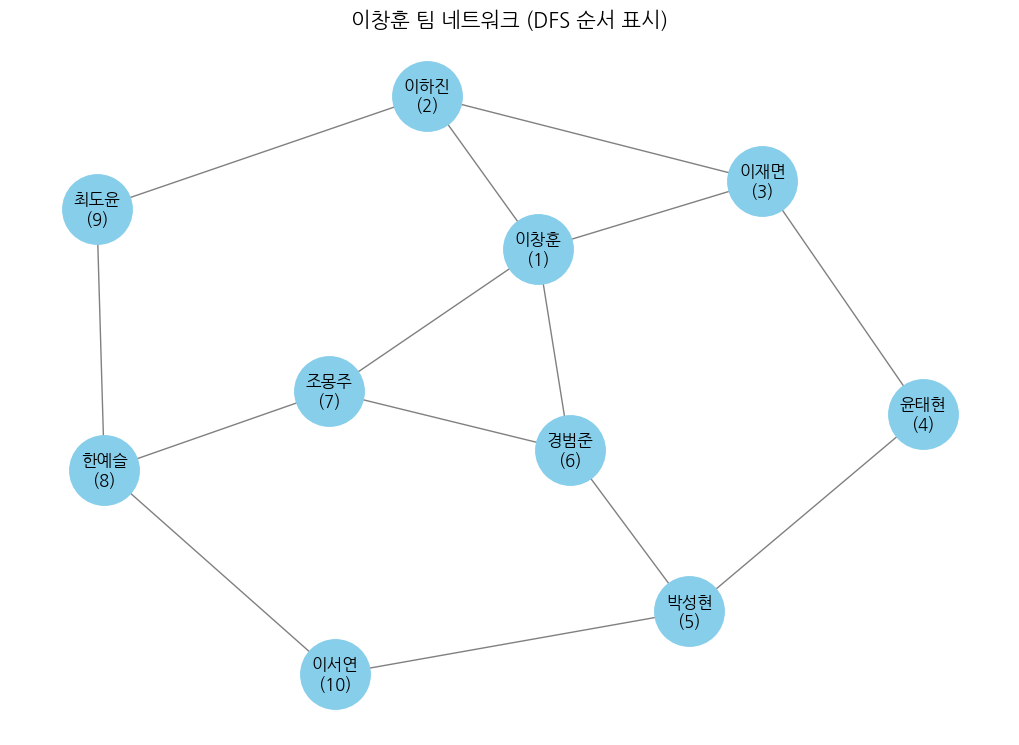

In [39]:
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import networkx as nx
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if not os.path.exists(font_path):
    raise FileNotFoundError("❌ 나눔고딕 폰트를 찾을 수 없습니다. 설치가 실패한 것 같습니다.")

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
mpl.rc('font', family=font_name)
mpl.rcParams['axes.unicode_minus'] = False

def dfs(graph, v, visited=None, path=None):
    if visited is None:
        visited = set()
    if path is None:
        path = []
    visited.add(v)
    path.append(v)
    for neighbor in graph[v]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, path)
    return path

dfs_order = dfs(graph, '이창훈')
print("DFS 탐색 순서:", " -> ".join(dfs_order))

G = nx.Graph()
for node, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)

node_colors = 'skyblue'
nx.draw(
    G, pos,
    with_labels=True,
    labels={node: f"{node}\n({dfs_order.index(node)+1})" for node in G.nodes()},
    node_color=node_colors,
    node_size=2500,
    font_size=12,
    font_family=font_name,
    font_weight='bold',
    edge_color='gray'
)

plt.title("이창훈 팀 네트워크 (DFS 순서 표시)", fontsize=15, fontfamily=font_name)
plt.show()


BFS 탐색 순서: 이창훈 -> 이하진 -> 이재면 -> 조몽주 -> 경범준 -> 최도윤 -> 윤태현 -> 한예슬 -> 박성현 -> 이서연


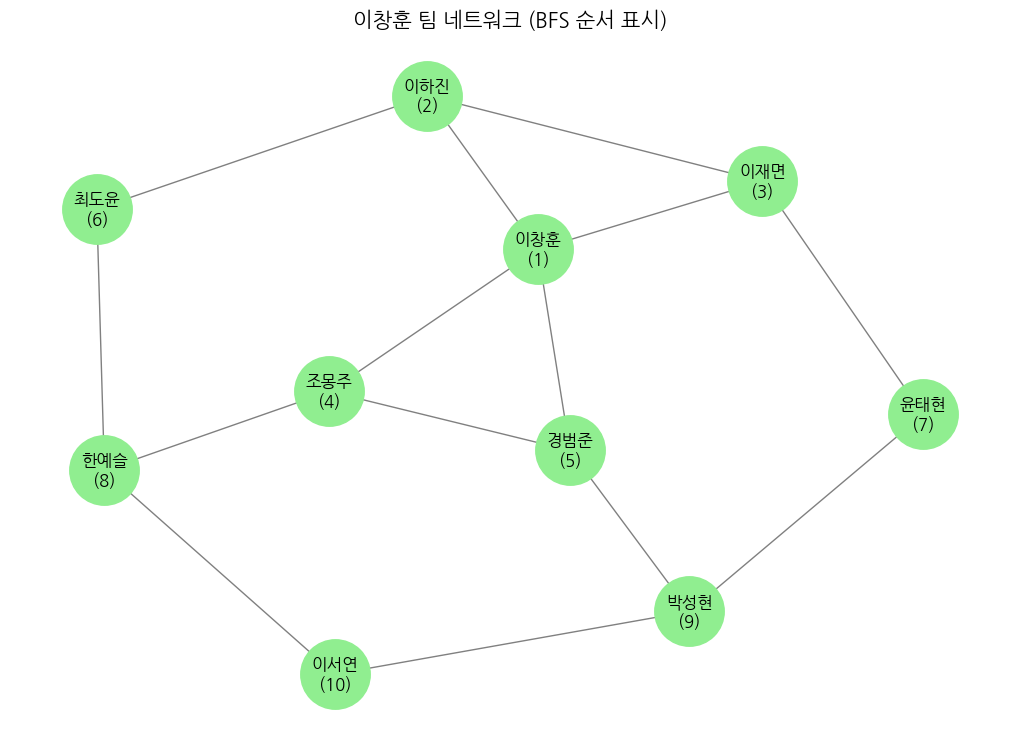

In [40]:
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import networkx as nx
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if not os.path.exists(font_path):
    raise FileNotFoundError("❌ 나눔고딕 폰트를 찾을 수 없습니다.")

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
mpl.rc('font', family=font_name)
mpl.rcParams['axes.unicode_minus'] = False

def bfs(graph, start):
    visited = set([start])
    queue = deque([start])
    path = []

    while queue:
        v = queue.popleft()
        path.append(v)
        for neighbor in graph[v]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return path

bfs_order = bfs(graph, '이창훈')
print("BFS 탐색 순서:", " -> ".join(bfs_order))

G = nx.Graph()
for node, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)

node_colors = 'lightgreen'
nx.draw(
    G, pos,
    with_labels=True,
    labels={node: f"{node}\n({bfs_order.index(node)+1})" for node in G.nodes()},
    node_color=node_colors,
    node_size=2500,
    font_size=12,
    font_family=font_name,
    font_weight='bold',
    edge_color='gray'
)

plt.title("이창훈 팀 네트워크 (BFS 순서 표시)", fontsize=15, fontfamily=font_name)
plt.show()



✅ 테스트케이스 하 (2단계 이내 감염)
🔵 1단계 감염자 (거리 1): 이하진, 이재면, 조몽주, 경범준
🔵 2단계 감염자 (거리 2): 최도윤, 윤태현, 한예슬, 박성현


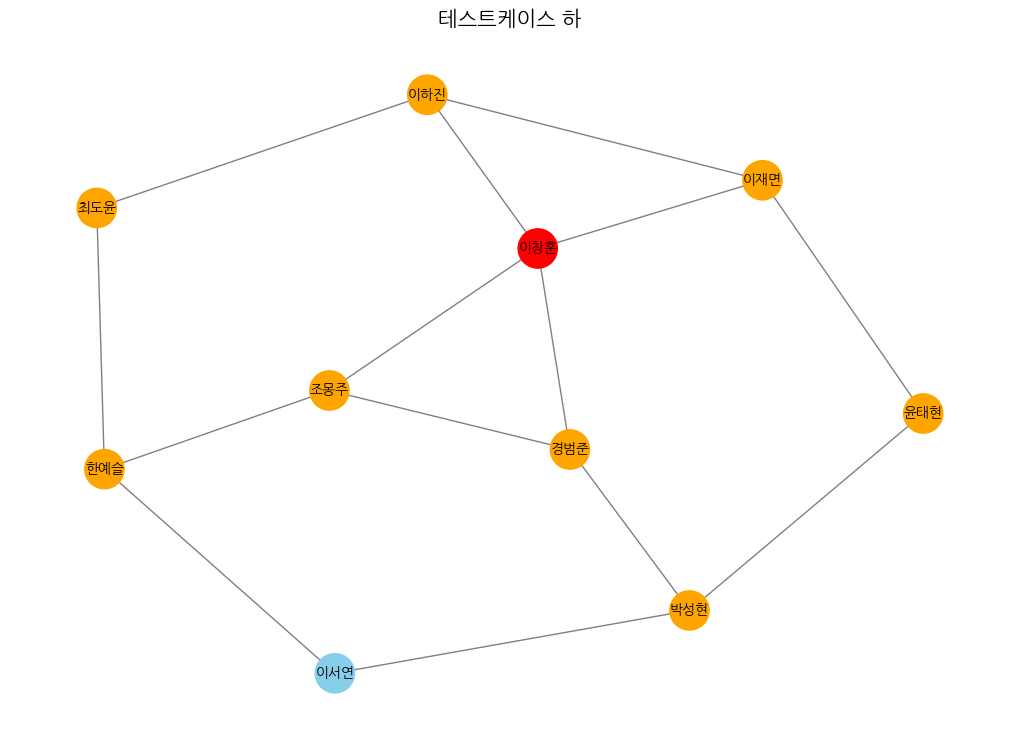


✅ 테스트케이스 중 (10단계 이내 감염)
🔵 1단계 감염자 (거리 1): 노드21, 노드57, 노드4, 노드78, 노드79
🔵 2단계 감염자 (거리 2): 노드15, 노드13, 노드32, 노드51, 노드52, 노드18, 노드55, 노드33, 노드49, 노드47, 노드58, 노드31, 노드50, 노드23, 노드88, 노드25, 노드98, 노드68, 노드7, 노드89
🔵 3단계 감염자 (거리 3): 노드19, 노드14, 노드92, 노드35, 노드36, 노드42, 노드73, 노드38, 노드63, 노드34, 노드84, 노드69, 노드22, 노드54, 노드60, 노드53, 노드74, 노드2, 노드59, 노드30, 노드8, 노드80, 노드83, 노드37, 노드16, 노드45, 노드82, 노드20, 노드41, 노드100, 노드26, 노드66, 노드11, 노드77, 노드97, 노드56, 노드39, 노드62, 노드72, 노드24, 노드61, 노드17, 노드43, 노드91, 노드28, 노드3, 노드12, 노드27, 노드81, 노드95, 노드76, 노드65, 노드86, 노드64, 노드67, 노드29, 노드85
🔵 4단계 감염자 (거리 4): 노드96, 노드40, 노드9, 노드44, 노드46, 노드5, 노드90, 노드75, 노드10, 노드70, 노드6, 노드48, 노드99, 노드94, 노드93, 노드87, 노드71


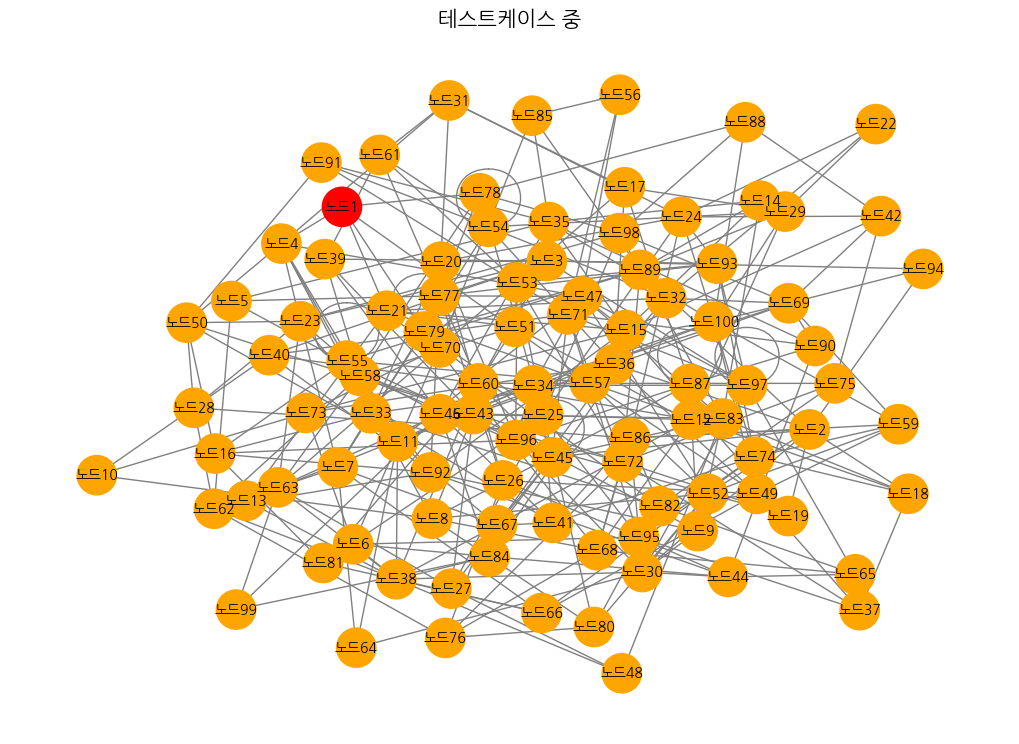


✅ 테스트케이스 상 (50단계 이내 감염)
🔵 1단계 감염자 (거리 1): 노드984, 노드449, 노드4, 노드287, 노드936
🔵 2단계 감염자 (거리 2): 노드694, 노드927, 노드513, 노드467, 노드92, 노드283, 노드690, 노드505, 노드741, 노드215, 노드293, 노드345, 노드452, 노드865, 노드564, 노드142, 노드156, 노드327, 노드611, 노드830, 노드763, 노드388, 노드660, 노드125, 노드321, 노드675, 노드468, 노드570, 노드747
🔵 3단계 감염자 (거리 3): 노드398, 노드626, 노드672, 노드577, 노드297, 노드633, 노드556, 노드849, 노드940, 노드979, 노드30, 노드8, 노드366, 노드840, 노드879, 노드390, 노드524, 노드915, 노드949, 노드901, 노드223, 노드254, 노드530, 노드896, 노드232, 노드576, 노드547, 노드617, 노드941, 노드501, 노드472, 노드905, 노드14, 노드194, 노드207, 노드795, 노드894, 노드995, 노드483, 노드911, 노드273, 노드456, 노드136, 노드13, 노드65, 노드80, 노드368, 노드475, 노드751, 노드928, 노드480, 노드637, 노드549, 노드36, 노드67, 노드81, 노드590, 노드605, 노드643, 노드686, 노드946, 노드498, 노드447, 노드122, 노드225, 노드866, 노드932, 노드385, 노드20, 노드360, 노드169, 노드952, 노드79, 노드120, 노드349, 노드532, 노드598, 노드654, 노드939, 노드811, 노드875, 노드313, 노드326, 노드695, 노드85, 노드968, 노드288, 노드931, 노드663, 노드957, 노드462, 노드334, 노드404, 노드757, 노드89, 노드819, 노드824, 노드63, 노드175, 노드274, 노드2

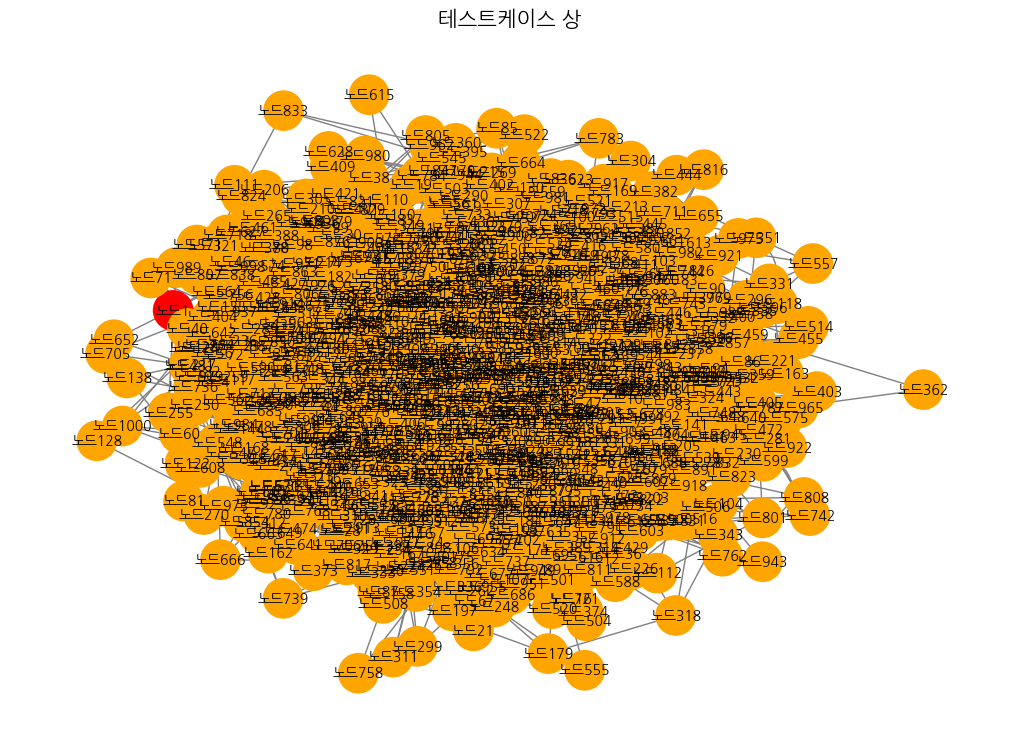

In [34]:
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import networkx as nx
import os
import random

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if not os.path.exists(font_path):
    raise FileNotFoundError("❌ 나눔고딕 폰트를 찾을 수 없습니다.")

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
mpl.rc('font', family=font_name)
mpl.rcParams['axes.unicode_minus'] = False

def infection_simulation(graph, patient_zero, max_depth):
    visited = {patient_zero: 0}  # 노드: 감염 단계(레벨)
    queue = deque([(patient_zero, 0)])
    while queue:
        current, depth = queue.popleft()
        if depth >= max_depth:
            continue
        for neighbor in graph.get(current, []):
            if neighbor not in visited:
                visited[neighbor] = depth + 1
                queue.append((neighbor, depth + 1))
    visited.pop(patient_zero)
    return visited

def print_infections_by_level(infected_dict):
    levels = {}
    for node, level in infected_dict.items():
        levels.setdefault(level, []).append(node)
    for level in sorted(levels.keys()):
        print(f"🔵 {level}단계 감염자 (거리 {level}): {', '.join(levels[level])}")

def plot_graph(graph, infected_nodes=None, patient_zero=None, title="Graph"):
    G = nx.Graph()
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
    plt.figure(figsize=(10,7))
    pos = nx.spring_layout(G, seed=42)
    node_colors = []
    for node in G.nodes():
        if node == patient_zero:
            node_colors.append('red')
        elif infected_nodes and node in infected_nodes:
            node_colors.append('orange')
        else:
            node_colors.append('skyblue')
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=800,
            font_size=10, font_weight='bold', edge_color='gray', font_family=font_name)
    plt.title(title, fontsize=15, fontfamily=font_name)
    plt.show()

# =========================
# 5️⃣ 테스트케이스 하
# =========================
graph_small = {
    '이창훈': ['이하진', '이재면', '조몽주', '경범준'],
    '이하진': ['이창훈', '이재면', '최도윤'],
    '이재면': ['이창훈', '이하진', '윤태현'],
    '조몽주': ['이창훈', '경범준', '한예슬'],
    '경범준': ['이창훈', '조몽주', '박성현'],
    '최도윤': ['이하진', '한예슬'],
    '윤태현': ['이재면', '박성현'],
    '박성현': ['경범준', '윤태현', '이서연'],
    '한예슬': ['조몽주', '최도윤', '이서연'],
    '이서연': ['한예슬', '박성현']
}
infected_small = infection_simulation(graph_small, '이창훈', max_depth=2)
print("\n✅ 테스트케이스 하 (2단계 이내 감염)")
print_infections_by_level(infected_small)
plot_graph(graph_small, infected_nodes=infected_small, patient_zero='이창훈', title="테스트케이스 하")

# =========================
# 6️⃣ 테스트케이스 중
# =========================
nodes_medium = [f'노드{i}' for i in range(1, 101)]
graph_medium = {node: random.sample(nodes_medium, k=random.randint(2,5)) for node in nodes_medium}
for node, neighbors in graph_medium.items():
    for neighbor in neighbors:
        if node not in graph_medium[neighbor]:
            graph_medium[neighbor].append(node)
infected_medium = infection_simulation(graph_medium, '노드1', max_depth=10)
print("\n✅ 테스트케이스 중 (10단계 이내 감염)")
print_infections_by_level(infected_medium)
plot_graph(graph_medium, infected_nodes=infected_medium, patient_zero='노드1', title="테스트케이스 중")

# =========================
# 7️⃣ 테스트케이스 상
# =========================
nodes_large = [f'노드{i}' for i in range(1, 1001)]
graph_large = {node: random.sample(nodes_large, k=random.randint(2,5)) for node in nodes_large}
for node, neighbors in graph_large.items():
    for neighbor in neighbors:
        if node not in graph_large[neighbor]:
            graph_large[neighbor].append(node)
infected_large = infection_simulation(graph_large, '노드1', max_depth=50)
print("\n✅ 테스트케이스 상 (50단계 이내 감염)")
print_infections_by_level(infected_large)
plot_graph(graph_large, infected_nodes=infected_large, patient_zero='노드1', title="테스트케이스 상")
